In [57]:
#################################################################
#                      Document History                           #
#                                                                 #
#  Author: Yupeng Zhu (NAU)(The Wang Lab-NAU)                     #         
#               <2023203050@stu.njau.edu.cn>                      # 
#                                                                 #
#                                                                 #
#    Date: 10th August 2025, V0.1 24th June 2023                   #
#    Version: 0.75 on TGAC internal Github                        #
#    Version: 1.18 on Github                                      #
#             https://github.com/The Wang Lab/RootScrout          #
#    requirements:                                                #
#               scikit-learn=1.2.1                                #
#               scikit-image=0.19.3                               #
#               matplotlib=3.7.0                                  #
#               pandas=1.5.3                                      #
#               numpy=1.23.5                                      #
#               scipy=1.10.0                                      #
#               seaborn=0.12.2                                    #
#               torch = 1.13.1                                    #
#               opencv-python = 4.7.0.72                          #
#                                                                 #
#    Changes:                                                     #
###################################################################


In [58]:
# ========== Import required packages ==========
from skimage import io, filters, measure, feature, future, color, morphology,draw
import numpy as np
import os
from PIL import Image
from yolo import YOLO
import time
import cv2
import scipy.ndimage as ndi
import matplotlib.pyplot as plt
from unet import Unet
import pandas as pd
from scipy.ndimage import binary_hit_or_miss
import math
import tqdm
import re
from scipy.optimize import linear_sum_assignment
from skimage.morphology import skeletonize
from scipy.spatial.distance import cdist
import numpy as np
from skimage.draw import disk
from scipy.spatial.distance import cdist
from skimage.draw import line
import numpy as np
from skimage.morphology import skeletonize
from skimage import io
from PIL import Image
from skimage.morphology import skeletonize, binary_closing, disk
from skimage.draw import line
from scipy.spatial.distance import cdist
from scipy.ndimage import binary_hit_or_miss
from skimage.graph import pixel_graph
from scipy.cluster.hierarchy import fclusterdata
from scipy.ndimage import binary_hit_or_miss, label, binary_dilation, center_of_mass
from scipy import ndimage

Part 1 : Germinating Seed Detection

Fusing layers... 
RepConv.fuse_repvgg_block
RepConv.fuse_repvgg_block
RepConv.fuse_repvgg_block
model_data/Weights_yolo.pth model, and classes loaded.
model_data/best_epoch_weights.pth model, and classes loaded.


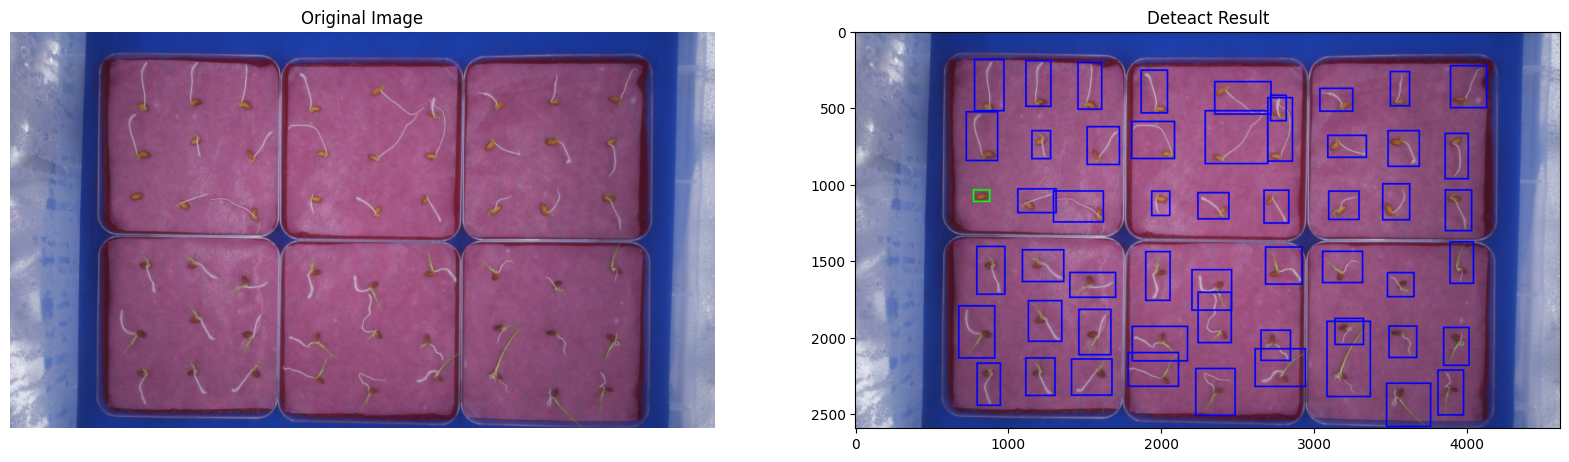

In [59]:

# ========== Load models ==========
def DeepLearning_Models():
    """Load YOLO and Unet models"""
    if not os.path.exists('yolo.py') or not os.path.exists('unet.py'):
        raise FileNotFoundError("YOLO and Unet model files are not found in the current directory.")
    yolo = YOLO()
    unet = Unet()
    return yolo, unet

if __name__ == "__main__":
    yolo ,unet = DeepLearning_Models()
    
    image = io.imread(r"Time-series data_sorted\root_100.jpg")
    r_image,BOX,radio = yolo.detect_image(Image.fromarray(image), region_coord=False, seed_num=9,crop = False, count=False)  
    plt.figure(figsize=(20, 20))   
    plt.subplot(1, 2, 1)
    plt.imshow(image)        
    plt.title('Original Image')
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.imshow(r_image)   
    plt.title('Deteact Result')
    


Part2 :Root Growth Tracking

In [60]:
# ========== File sorting ==========
def sorted_file(Dir_path):
    filenames = [f for f in os.listdir(Dir_path) if f.lower().endswith(('.jpg', '.png', '.jpeg', '.tif'))]
    def atoi(text):
        return int(text) if text.isdigit() else text
    def natural_keys(text):
        return [atoi(c) for c in re.split(r'(\d+)', text)]
    return sorted(filenames, key=natural_keys)
   
 

In [61]:
# ========== Region segmentation ==========
def seg_region(image):
    lab_image = color.rgb2lab(image)
    thresh = filters.threshold_otsu((lab_image[:,:,2] > filters.threshold_otsu(lab_image[:,:,2])) * lab_image[:,:,1])
    origin_mask = ((lab_image[:,:,2] > filters.threshold_otsu(lab_image[:,:,2])) * lab_image[:,:,1]) > thresh
    origin_mask = morphology.dilation(origin_mask, morphology.disk(15))
    origin_mask_fill = ndi.binary_fill_holes(origin_mask)
    contours, _ = cv2.findContours(origin_mask_fill.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    max_contour = max(contours, key=cv2.contourArea)
    img = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)
    x, y, w, h = cv2.boundingRect(max_contour)
    from skimage.draw import line, rectangle
    img1 = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)
    img2 = morphology.erosion(img1.copy(), morphology.disk(1))
    rr1, cc1 = line(int((y + h/2)), x, int(y + h/2), x + w)
    rr2, cc2 = line(y, int(x + w/3), y + h - 1, int(x + w/3))
    rr3, cc3 = line(y, int(x + (w/3)*2), y + h - 1, int(x + (w/3)*2))
    rr4, cc4 = rectangle((y, x), (y + h, x + w), shape=img.shape)
    img1[rr1, cc1] = 1
    img1[rr2, cc2] = 1
    img1[rr3, cc3] = 1
    img1 = morphology.dilation(img1, morphology.disk(2))
    img2[rr4, cc4] = 1
    img3 = np.where(img1 > 0, 0, 1) * img2
    return img3, x, y, w, h

In [62]:
# ========== Helper functions Tracking based on IoU and Kalman filter==========
def computer_coord(box):
    top, left, bottom, right = box
    top = max(0, np.floor(top).astype('int32'))
    left = max(0, np.floor(left).astype('int32'))
    return (np.int32((bottom - top)/2 + top), np.int32((left + (right - left)/2)))

def create_kalman():
    kf = cv2.KalmanFilter(4, 2)
    kf.transitionMatrix = np.array([[1, 0, 1, 0], [0, 1, 0, 1], [0, 0, 1, 0], [0, 0, 0, 1]], dtype=np.float32)
    kf.measurementMatrix = np.array([[1, 0, 0, 0], [0, 1, 0, 0]], dtype=np.float32)
    kf.processNoiseCov = np.eye(4, dtype=np.float32) * 0.05
    kf.measurementNoiseCov = np.eye(2, dtype=np.float32) * 0.5
    kf.errorCovPost = np.eye(4, dtype=np.float32) * 0.1
    return kf

def compute_iou(box1, box2):
    x1 = max(box1[1], box2[1])
    y1 = max(box1[0], box2[0])
    x2 = min(box1[3], box2[3])
    y2 = min(box1[2], box2[2])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[3] - box1[1]) * (box1[2] - box1[0])
    area2 = (box2[3] - box2[1]) * (box2[2] - box2[0])
    union = area1 + area2 - inter
    return inter / union if union > 0 else 0.0

def get_color(seed, total=None):
    if total is None:
        hue = (seed * 50 + 30) % 180
    else:
        hue = int(seed * (180 / total)) % 180
    hsv = np.array([hue, 255, 255], dtype=np.uint8)
    bgr = cv2.cvtColor(np.array([[hsv]]), cv2.COLOR_HSV2BGR)[0][0]
    return tuple(int(c) for c in bgr[::-1])

Processed 1/100 frames
Processed 2/100 frames
Processed 3/100 frames
Processed 4/100 frames
Processed 5/100 frames
Processed 6/100 frames
Processed 7/100 frames
Processed 8/100 frames
Processed 9/100 frames
Processed 10/100 frames
Processed 11/100 frames
Processed 12/100 frames
Processed 13/100 frames
Processed 14/100 frames
Processed 15/100 frames
Processed 16/100 frames
Processed 17/100 frames
Processed 18/100 frames
Processed 19/100 frames
Processed 20/100 frames
Processed 21/100 frames
Processed 22/100 frames
Processed 23/100 frames
Processed 24/100 frames
Processed 25/100 frames
Processed 26/100 frames
Processed 27/100 frames
Processed 28/100 frames
Processed 29/100 frames
Processed 30/100 frames
Processed 31/100 frames
Processed 32/100 frames
Processed 33/100 frames
Processed 34/100 frames
Processed 35/100 frames
Processed 36/100 frames
Processed 37/100 frames
Processed 38/100 frames
Processed 39/100 frames
Processed 40/100 frames
Processed 41/100 frames
Processed 42/100 frames
P

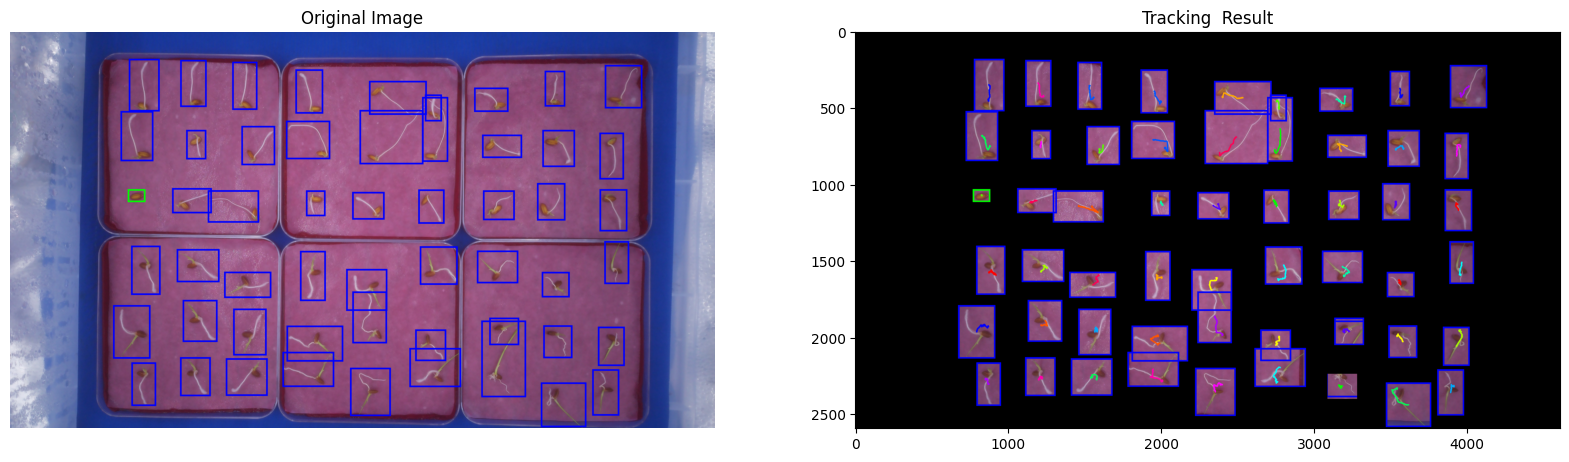

In [63]:
# ========== Tracking ==========
def get_box(dir_path, sorted_filenames_natural, yolo, unet,show_image = False):
   
    region_path = os.path.join(dir_path, sorted_filenames_natural[0])
    img = io.imread(region_path)
    region_mask, x, y, w, h = seg_region(img)
    coord1 = [x, y, x + w/3, y + h/2]
    coord2 = [x + w/3, y, x + 2*w/3, y + h/2]
    coord3 = [x + 2*w/3, y, x + w, y + h/2]
    coord4 = [x, y + h/2, x + w/3, y + h]
    coord5 = [x + w/3, y + h/2, x + 2*w/3, y + h]
    coord6 = [x + 2*w/3, y + h/2, x + w, y + h]
    region_coord = [coord1, coord2, coord3, coord4, coord5, coord6]

    SAVE_DIR = os.path.join(os.getcwd(), "SINGLE_DETEXT_IMAGE")
    os.makedirs(SAVE_DIR, exist_ok=True)

    kalman_filters = {}
    target_history = {}
    target_colors = {}
    target_last_boxes = {}
    target_box_sizes = {}
    ordered_ids = []
    trajectories = {}
    next_id = 0
    IOU_THRESHOLD = 0.3

    for i, file_name in enumerate(sorted_filenames_natural):
        image_path = os.path.join(dir_path, file_name)
        image = Image.open(image_path)
        r_image, BOX_current, radio = yolo.detect_image(
            image, region_coord, seed_num=9, crop=False, count=False
        )
        if isinstance(BOX_current, np.ndarray):
            BOX_current = BOX_current.tolist()

        curr_boxes = BOX_current
        curr_centroids = []
        for box in curr_boxes:
            top, left, bottom, right = box
            cx = int(left + (right - left) / 2)
            cy = int(top + (bottom - top) / 2)
            curr_centroids.append((cx, cy))

        predicted_positions = {}
        for tid, kf in kalman_filters.items():
            pred = kf.predict()
            predicted_positions[tid] = (int(pred[0]), int(pred[1]))

        if i == 0:
            for box, centroid in zip(curr_boxes, curr_centroids):
                new_tid = next_id
                next_id += 1
                kf = create_kalman()
                kf.statePre = np.array([[centroid[0]], [centroid[1]], [0.], [0.]], dtype=np.float32)
                kf.statePost = np.array([[centroid[0]], [centroid[1]], [0.], [0.]], dtype=np.float32)
                kalman_filters[new_tid] = kf
                target_history[new_tid] = [centroid]
                target_colors[new_tid] = get_color(new_tid)
                target_last_boxes[new_tid] = box
                target_box_sizes[new_tid] = (box[3] - box[1], box[2] - box[0])
                ordered_ids.append(new_tid)
                trajectories[new_tid] = [box]
            print(f"Processed {i+1}/{len(sorted_filenames_natural)} frames")
            continue

        matched_pairs = {}
        used_curr = set()
        active_ids = [tid for tid in ordered_ids]

        if active_ids and curr_boxes:
            cost_matrix = np.zeros((len(active_ids), len(curr_boxes)))
            for r, tid in enumerate(active_ids):
                prev_box = target_last_boxes[tid]
                for c, curr_box in enumerate(curr_boxes):
                    iou = compute_iou(prev_box, curr_box)
                    cost_matrix[r, c] = 1 - iou
            row_ind, col_ind = linear_sum_assignment(cost_matrix)
            for r, c in zip(row_ind, col_ind):
                iou = 1 - cost_matrix[r, c]
                if iou >= IOU_THRESHOLD:
                    tid = active_ids[r]
                    matched_pairs[tid] = c
                    used_curr.add(c)

        for tid, curr_idx in matched_pairs.items():
            measurement = curr_centroids[curr_idx]
            kalman_filters[tid].correct(np.array([[measurement[0]], [measurement[1]]], dtype=np.float32))
            target_history[tid].append(measurement)
            target_last_boxes[tid] = curr_boxes[curr_idx]
            box = curr_boxes[curr_idx]
            target_box_sizes[tid] = (box[3] - box[1], box[2] - box[0])

        current_boxes_for_tid = {}
        for tid in ordered_ids:
            if tid in matched_pairs:
                box = curr_boxes[matched_pairs[tid]]
            else:
                pred_cx, pred_cy = predicted_positions[tid]
                w_old, h_old = target_box_sizes[tid]
                box = [pred_cy - h_old//2, pred_cx - w_old//2,
                       pred_cy + h_old//2, pred_cx + w_old//2]
                target_last_boxes[tid] = box
            current_boxes_for_tid[tid] = box

        for tid in ordered_ids:
            trajectories[tid].append(current_boxes_for_tid[tid])

        black_bg = np.zeros((img.shape[0], img.shape[1], 3), dtype=np.uint8)
        for tid in ordered_ids:
            if tid in target_last_boxes:
                box = target_last_boxes[tid]
                top, left, bottom, right = map(int, box)
                top = max(0, top); left = max(0, left)
                bottom = min(img.shape[0], bottom); right = min(img.shape[1], right)
                cropped = np.array(image.crop((left, top, right, bottom)))
                black_bg[top:bottom, left:right] = cropped

        for tid in ordered_ids:
            coords = target_history.get(tid, [])
            if len(coords) >= 2:
                pts = np.array(coords, dtype=np.int32)
                color = target_colors[tid]
                cv2.polylines(black_bg, [pts], isClosed=False, color=color, thickness=8, lineType=cv2.LINE_AA)

        save_path = os.path.join(SAVE_DIR, file_name)
        cv2.imwrite(save_path, cv2.cvtColor(black_bg, cv2.COLOR_RGB2BGR))
        
        print(f"Processed {i+1}/{len(sorted_filenames_natural)} frames")
    if show_image == True:
        plt.figure(figsize=(20,20))
        plt.subplot(1, 2, 1)
        plt.imshow(np.array(image))        
        plt.title('Original Image')
        plt.axis('off')
        plt.subplot(1, 2, 2)
        plt.imshow(black_bg)   
        plt.title('Tracking  Result')

    BOX = [trajectories[tid] for tid in ordered_ids]
    BOX = [[np.array(box, dtype=np.float32) for box in traj] for traj in BOX]
    return BOX, region_coord
if __name__ == "__main__":
    # pass
    dir_path = "Time-series data_sorted"  # Please change to actual path
    sorted_filenames_natural = sorted_file(dir_path)
    BOX, region_coord = get_box(dir_path, sorted_filenames_natural, yolo, unet, show_image= True)
 

Part 3:Post-processing: skeleton pruning and merging of crossed root fragments based on a single seed

In [64]:
# ========== Region division ==========
def get_six_region(BOX, region_coord):
    regions = [[] for _ in range(6)]
    for traj in BOX:
        top, left, bottom, right = traj[0]
        centroid = (int(left + (right - left) / 2), int(top + (bottom - top) / 2))
        for idx, coord in enumerate(region_coord):
            if coord[0] < centroid[0] < coord[2] and coord[1] < centroid[1] < coord[3]:
                regions[idx].append(traj)
                break
    return regions


In [65]:
# ========== Keep largest area mask ==========
def segmation_rol(mask):
    from skimage import measure
    label_img = measure.label(mask)
    properties = measure.regionprops(label_img)
    if not properties:
        return mask
    a = [prop.area for prop in properties]
    valid_label = set()
    for prop in properties:
        if prop.area == max(a):
            valid_label.add(prop.label)
    big_mask = np.in1d(label_img, list(valid_label)).reshape(label_img.shape)
    return big_mask

In [66]:
# ========== Endpoint and branch detection ==========
def find_end_points(skel):
    struct1, origin1 = np.array([[0, 0, 0], [0, 1, 0]]), (0, 0)
    struct2, origin2 = np.array([[0, 0], [0, 1], [0, 0]]), (0, 0)
    struct3, origin3 = np.array([[0, 1, 0], [0, 0, 0]]), (-1, 0)
    struct4, origin4 = np.array([[0, 0], [1, 0], [0, 0]]), (0, -1)
    ret = None
    for struct, origin in [(struct1, origin1), (struct2, origin2), (struct3, origin3), (struct4, origin4)]:
        if ret is None:
            ret = binary_hit_or_miss(skel, structure1=struct, origin1=origin)
        else:
            ret = np.logical_or(ret, binary_hit_or_miss(skel, structure1=struct, origin1=origin))
    return np.nonzero(ret)[::-1]

def find_end_image(img, sk1, font=cv2.FONT_HERSHEY_SIMPLEX, font_size=3, font_thickness=2):
    ret = find_end_points(sk1)
    black_im = np.zeros((img.shape[0], img.shape[1]))
    peak_counter = 0
    for i in range(len(ret[0])):
        black_im[ret[1][i], ret[0][i]] = 1
        text = str(peak_counter + 1)
        (text_w, text_h), baseline = cv2.getTextSize(text, font, font_size, font_thickness)
        tx = int(round(ret[0][i] - (text_w / 2.0)))
        ty = int(round(ret[1][i] + (text_h / 2.0)))
        cv2.circle(img, (ret[0][i], ret[1][i]), 5, (255, 255, 0), -1)
        cv2.circle(img, (ret[0][i], ret[1][i]), 1, (255, 0, 0), 1)
        cv2.putText(img, text, (tx, ty), font, font_size, (255, 0, 0), font_thickness)
        peak_counter += 1
    return black_im, img, ret

def find_branches(skel):
    """Detect branching points of a skeleton (return (N,2) array of (row, col) coordinates)"""
    struct1 = np.array([[0, 1, 0], [0, 1, 0], [1, 0, 1]])
    struct2 = np.array([[1, 0, 0], [0, 1, 1], [0, 1, 0]])
    struct3 = np.array([[1, 0, 0], [0, 1, 0], [1, 0, 1]])
    struct4 = np.array([[0, 0, 0], [1, 1, 1], [0, 1, 0]])
    struct5 = np.array([[0, 1, 0], [1, 1, 1], [0, 1, 0]])

    structs = [np.rot90(struct1, i) for i in range(4)]
    structs += [np.rot90(struct2, i) for i in range(4)]
    structs += [np.rot90(struct3, i) for i in range(4)]
    structs += [np.rot90(struct4, i) for i in range(4)]
    structs += [np.rot90(struct5, i) for i in range(4)]

    ret = None
    for i in range(len(structs)):
        if ret is None:
            ret = binary_hit_or_miss(skel, structure1=structs[i])
        else:
            ret = np.logical_xor(ret, binary_hit_or_miss(skel, structure1=structs[i]))

    return np.transpose(np.nonzero(ret))  


In [67]:
# ========== Branch point detection and adjacent point merging ==========


def find_branches_robust_v2(skeleton, 
                            min_branch_length=5, 
                            merge_dist=3, 
                            use_graph=True, 
                            use_clustering=True):
    """
    Multi_strategy fusion for branch point detection to improve recall.

    Parameters:
        skeleton: binary skeleton image (bool)
        min_branch_length: minimum length (in pixels) for each branch, used to filter spurs
        merge_dist: distance for merging nearby branch points
        use_graph: whether to enable graph_topology detection (good for nodes with degree > 2)
        use_clustering: whether to enable directional_clustering detection (good for branch junction regions)

    Returns:
        coords: (N,2) branch point coordinates (row, column)
    """
    # ---- Method 1: pattern matching (original find_branches) ----
    candidates = find_branches(skeleton)  # assumed to be defined elsewhere
    if len(candidates) > 0:
        candidates = candidates.tolist()
    else:
        candidates = []

    # ---- Method 2: graph‑topology detection (degree > 2) ----
    if use_graph:
        try:
            graph, nodes = pixel_graph(skeleton, connectivity=2)
            degrees = np.sum(graph, axis=1)
            graph_branches = nodes[degrees > 2].tolist()
            candidates.extend(graph_branches)
        except Exception as e:
            print(f"Graph‑topology detection failed: {e}")

    # ---- Method 3: directional‑clustering detection ----
    if use_clustering:
        try:
            cluster_branches = detect_branches_by_direction_clustering(skeleton, eps=3, min_samples=3)
            candidates.extend(cluster_branches.tolist())
        except Exception as e:
            print(f"Direction‑clustering detection failed: {e}")

    if not candidates:
        return np.array([])

    # ---- Deduplication and merging ----
    # Convert to numpy array and deduplicate (round coordinates)
    candidates = np.unique(np.array(candidates), axis=0)

    # ---- Validate branch length ----
    valid = []
    for (r, c) in candidates:
        # Check whether the point is actually on the skeleton
        if not skeleton[r, c]:
            continue
        # Obtain branch directions (8‑neighbourhood skeleton pixels)
        neighbors = []
        for dr in (-1,0,1):
            for dc in (-1,0,1):
                if dr==0 and dc==0: continue
                nr, nc = r+dr, c+dc
                if 0 <= nr < skeleton.shape[0] and 0 <= nc < skeleton.shape[1]:
                    if skeleton[nr, nc]:
                        neighbors.append((nr, nc))
        if len(neighbors) < 3:
            continue

        # Trace the length of each branch
        lengths = []
        for start in neighbors:
            length = 1
            prev = (r, c)
            current = start
            while length < min_branch_length:
                # Find the next unvisited skeleton point
                nxt = None
                for dr2 in (-1,0,1):
                    for dc2 in (-1,0,1):
                        if dr2==0 and dc2==0: continue
                        nr2, nc2 = current[0]+dr2, current[1]+dc2
                        if 0 <= nr2 < skeleton.shape[0] and 0 <= nc2 < skeleton.shape[1]:
                            if skeleton[nr2, nc2] and (nr2, nc2) != prev:
                                nxt = (nr2, nc2)
                                break
                    if nxt is not None:
                        break
                if nxt is None:
                    break
                prev, current = current, nxt
                length += 1
            lengths.append(length)
        if all(l >= min_branch_length for l in lengths):
            valid.append((r, c))

    if not valid:
        return np.array([])

    valid = np.array(valid)

    # ---- Nearby merging ----
    if len(valid) > 1:
        try:
            labels = fclusterdata(valid, merge_dist, criterion='distance')
            merged = []
            for lab in np.unique(labels):
                cluster = valid[labels == lab]
                merged.append(np.mean(cluster, axis=0).astype(int))
            valid = np.array(merged)
        except:
            # Fallback: dilation + connected‑component centroid
            mask = np.zeros(skeleton.shape, dtype=bool)
            mask[valid[:,0], valid[:,1]] = True
            struct = np.ones((merge_dist*2+1, merge_dist*2+1))
            dilated = binary_dilation(mask, structure=struct)
            labeled, num = label(dilated)
            merged = []
            for i in range(1, num+1):
                cy, cx = center_of_mass(labeled == i)
                merged.append((int(round(cy)), int(round(cx))))
            valid = np.array(merged)

    return valid


def detect_branches_by_direction_clustering(skeleton, eps=3, min_samples=3):
    """
    Branch point detection based on local direction clustering.
    For each skeleton pixel, compute the local principal direction, then cluster them.
    Regions with large direction changes are considered branch point candidates.
    """
    coords = np.argwhere(skeleton)  # (N,2) rows, columns
    if len(coords) < 10:
        return np.array([])

    # Compute local direction for each point (fit a line using neighbouring points)
    directions = []
    for (r, c) in coords:
        # Take the 3x3 neighbourhood around the point
        patch = skeleton[max(0,r-1):r+2, max(0,c-1):c+2]
        if np.sum(patch) < 3:
            directions.append(0)
            continue
        # Coordinates of points in the patch (relative to centre)
        rows, cols = np.where(patch)
        rows = rows - 1  # offset from centre
        cols = cols - 1
        if len(rows) < 2:
            directions.append(0)
            continue
        # Compute covariance matrix and find principal direction
        pts = np.column_stack((rows, cols))
        cov = np.cov(pts.T)
        if cov.shape != (2,2):
            directions.append(0)
            continue
        eig_vals, eig_vecs = np.linalg.eig(cov)
        if np.max(eig_vals) < 1e-6:
            directions.append(0)
            continue
        direction = eig_vecs[:, np.argmax(eig_vals)]
        angle = np.arctan2(direction[1], direction[0])
        directions.append(angle)

    directions = np.array(directions)

    # Use DBSCAN for clustering (on direction angles, points with similar direction belong to same branch)
    # However, we adopt a simpler approach: for each point, compute the standard deviation of directions
    # in its neighbourhood; if it exceeds a threshold, mark it as a candidate.
    candidates = []
    for i, (r, c) in enumerate(coords):
        # Find neighbours within radius eps
        dists = np.sqrt((coords[:,0]-r)**2 + (coords[:,1]-c)**2)
        neighbors = dists < eps
        if np.sum(neighbors) < min_samples:
            continue
        dir_vals = directions[neighbors]
        # If the direction variance is large, a fork likely exists
        # But directions are periodic (-π,π), so handle wrap‑around
        # Simple approach: compute maximum deviation from the median
        if len(dir_vals) > 2:
            max_diff = np.max(np.abs(dir_vals - np.median(dir_vals)))
            if max_diff > np.pi/6:  # difference > 30°
                candidates.append((r, c))

    return np.unique(np.array(candidates), axis=0)

In [68]:
# ========== Broken root connection ==========
def get_endpoint_direction(skel, y, x, length=10):
    """
    Trace `length` pixels along the skeleton and estimate the direction angle (radians) using PCA.
    Returns: direction angle (radians) or None if the trace length is insufficient.
    """
    points = [(y, x)]
    prev = (y, x)
    current = (y, x)
    for _ in range(length - 1):
        neighbors = []
        for dy in (-1,0,1):
            for dx in (-1,0,1):
                if dy==0 and dx==0:
                    continue
                ny, nx = current[0] + dy, current[1] + dx
                if 0 <= ny < skel.shape[0] and 0 <= nx < skel.shape[1]:
                    if skel[ny, nx] and (ny, nx) != prev:
                        neighbors.append((ny, nx))
        if not neighbors:
            break
        prev, current = current, neighbors[0]
        points.append(current)
    if len(points) < 2:
        return None
    pts = np.array(points)
    mean = np.mean(pts, axis=0)
    centered = pts - mean
    cov = np.cov(centered.T)
    eig_vals, eig_vecs = np.linalg.eig(cov)
    direction = eig_vecs[:, np.argmax(eig_vals)]
    angle = np.arctan2(direction[1], direction[0])
    return angle


def angle_diff(a1, a2):
    """Calculate the minimum angle between two angles (radians), ranging from 0 to π."""
    diff = a1 - a2
    diff = np.arctan2(np.sin(diff), np.cos(diff))
    return abs(diff)


def connect_broken_pieces(mask, max_dist=30, angle_thresh=np.pi/16, 
                          min_track_len=5, verbose=True, auto_repair=False):
    """
    Reconnect broken roots: connect fractured parts based on endpoint distance and direction consistency.
    
    Parameters:
        mask           : Binary root mask (True/False or 0/1)
        max_dist       : Maximum connection distance (pixels)
        angle_thresh   : Maximum direction angle (radians), default 30°
        min_track_len  : Minimum trace length for endpoints. Endpoints below this value are treated as noise and ignored.
        verbose        : Whether to print detailed information
        auto_repair    : Whether to attempt morphological closing repair if endpoints are insufficient
        
    Returns:
        repaired_mask  : Binary mask after connection
        stats          : Dictionary containing connection information
    """
    original_mask = mask.astype(bool)
    skel = skeletonize(mask)
    
    # Detect endpoints
    xs, ys = find_end_points(skel)          # xs: columns, ys: rows
    endpoints = np.column_stack((ys, xs))   # Convert to (y, x)
    
    if verbose:
        print(f"Number of skeleton pixels: {np.sum(skel)}")
        print(f"Original number of endpoints: {len(endpoints)}")
    
    # Filter out endpoints that are too short (trace length < min_track_len)
    valid_endpoints = []
    for y, x in endpoints:
        ang = get_endpoint_direction(skel, y, x, length=10)
        # If direction calculation fails or the trace length is insufficient, ignore this endpoint
        if ang is not None:
            # For simplicity, we can write a new tracking function, but here we assume that if ang is not None, the length is sufficient.
            valid_endpoints.append((y, x, ang))
    
    if len(valid_endpoints) < 2:
        if verbose:
            print("Insufficient valid endpoints for pairing.")
        if auto_repair:
            closed = binary_closing(mask, disk(5))
            return connect_broken_pieces(closed, max_dist, angle_thresh, 
                                         min_track_len, verbose, auto_repair=False)
        return mask
    
    # Separate coordinates and angles
    coords = np.array([(p[0], p[1]) for p in valid_endpoints])
    angles = np.array([p[2] for p in valid_endpoints])
    
    if verbose:
        print(f"Number of valid endpoints: {len(coords)}")
    
    # Calculate distance matrix
    dist_mat = cdist(coords, coords)
    
    # Pairing connections
    repaired = mask.copy().astype(bool)
    connect_count = 0
    for i in range(len(coords)):
        for j in range(i+1, len(coords)):
            dist = dist_mat[i, j]
            if dist < max_dist:
                ang_diff = angle_diff(angles[i], angles[j])
                if ang_diff < angle_thresh:
                    # Connect two endpoints
                    y1, x1 = coords[i]
                    y2, x2 = coords[j]
                    rr, cc = line(y1, x1, y2, x2)
                    repaired[rr, cc] = True
                    connect_count += 1
                    if verbose:
                        print(f"✅ Connected endpoints {i} and {j}: distance={dist:.2f}, angle difference={np.degrees(ang_diff):.1f}°")
    
    if verbose:
        print(f"Total connected {connect_count} pairs of endpoints")
    
    # Return the connected mask and statistics
    stats = {'endpoints_total': len(endpoints),
             'valid_endpoints': len(coords),
             'connections': connect_count}
    return repaired.astype(np.uint8)

In [69]:
#============= Segment roots based on connected component cutting========================
def prune_short_branches(skeleton, radius=3, min_branch_length=5):

    coord_branch = find_branches_robust_v2(skeleton)
    arr = np.array(coord_branch)
    points_branch_coord = list(map(tuple, arr))
    mask_branch = np.zeros(skeleton.shape, dtype=bool)

    for center in points_branch_coord:
        rr, cc = draw.disk(center, radius, shape=mask_branch.shape)
        mask_branch[rr, cc] = True
    # ### Mask for cut branches
    branch_cut_mask = skeleton * np.where(mask_branch > 0, 0, 1).astype(np.uint8)

    labeled = measure.label(branch_cut_mask, connectivity=2)  # connectivity=2 means 8-neighborhood
    # Create filtered mask
    filtered_mask = np.zeros_like(branch_cut_mask, dtype=bool)
    for prop in measure.regionprops(labeled):
        if prop.area >= min_branch_length:
            filtered_mask[labeled == prop.label] = True
    return filtered_mask, branch_cut_mask

In [70]:
#================= Lateral root separation based on computer graph theory ==================
def prune_skeleton(skeleton, min_branch_length=5):
    """
    Prune terminal branches (spurs) with length less than the threshold from a binary skeleton.

    Parameters:
        skeleton: Binary array (H, W), True/False or 0/1, skeleton pixels are True/1.
        min_branch_length: Minimum branch length to keep (in pixels); terminal branches shorter than this will be removed.

    Returns:
        pruned: Binary array with the same shape as skeleton, the pruned skeleton.
    """
    skel = skeleton.astype(bool)
    h, w = skel.shape

    # Compute the number of neighbours (8‑connectivity) for each skeleton pixel
    kernel = np.ones((3, 3), dtype=np.uint8)
    neighbor_count = ndimage.convolve(skel.astype(np.uint8), kernel, mode='constant') * skel
    neighbor_count = neighbor_count - 1  # subtract the pixel itself

    endpoints = (neighbor_count == 1) & skel
    branch_points = (neighbor_count >= 3) & skel

    # Label all endpoints, then trace branches starting from each endpoint
    labels, num_labels = ndimage.label(endpoints, structure=np.ones((3,3)))
    to_remove = np.zeros_like(skel, dtype=bool)
    visited = np.zeros_like(skel, dtype=bool)

    for label_id in range(1, num_labels + 1):
        seed_points = np.argwhere(labels == label_id)
        if len(seed_points) == 0:
            continue
        start_y, start_x = seed_points[0]
        branch_mask = _trace_branch(skel, start_y, start_x, branch_points, visited)
        branch_length = np.sum(branch_mask)
        if branch_length < min_branch_length:
            to_remove |= branch_mask

    # Keep branch points to avoid disconnection
    to_remove &= ~branch_points
    pruned = skel & ~to_remove
    return pruned

def _trace_branch(skel, start_y, start_x, branch_points, visited):
    """Trace a branch from an endpoint to a branch point or terminus, returning a mask of the branch."""
    h, w = skel.shape
    branch = np.zeros_like(skel, dtype=bool)
    current_y, current_x = start_y, start_x
    prev_y, prev_x = -1, -1

    while True:
        branch[current_y, current_x] = True
        visited[current_y, current_x] = True

        if branch_points[current_y, current_x]:
            break

        neighbors = _get_neighbors(current_y, current_x, h, w)
        next_candidates = []
        for ny, nx in neighbors:
            if skel[ny, nx] and (ny != prev_y or nx != prev_x) and not visited[ny, nx]:
                next_candidates.append((ny, nx))

        if not next_candidates:
            break
        if len(next_candidates) > 1:
            # If multiple branches emerge, treat as a branch point and stop
            break

        prev_y, prev_x = current_y, current_x
        current_y, current_x = next_candidates[0]

    return branch

def _get_neighbors(y, x, h, w):
    neighbors = []
    for dy in (-1, 0, 1):
        for dx in (-1, 0, 1):
            if dy == 0 and dx == 0:
                continue
            ny, nx = y + dy, x + dx
            if 0 <= ny < h and 0 <= nx < w:
                neighbors.append((ny, nx))
    return neighbors

In [71]:
#=================== Keep only the main root, primary root =========================
def keep_main_branch(skeleton):
    """
    Extract the longest trunk (tree diameter) from a binary skeleton, removing all lateral branches.

    Parameters:
        skeleton: Binary image (H, W), skeleton pixels are True or 1.

    Returns:
        main_branch: Binary image containing only the pixels on the longest path.
    """
    skel = skeleton.astype(bool)
    if not np.any(skel):
        return skel

    # 1. Label all connected components (in case the skeleton is disconnected)
    labeled, num_features = ndimage.label(skel, structure=np.ones((3,3)))
    if num_features == 0:
        return skel

    # 2. Extract the main branch for each connected component separately, then merge
    main_branch = np.zeros_like(skel, dtype=bool)
    for comp_id in range(1, num_features + 1):
        comp_mask = (labeled == comp_id)
        # Extract the skeleton graph of this component: node coordinates and adjacency
        main_comp = _extract_single_component_main(comp_mask)
        main_branch |= main_comp

    return main_branch


def _extract_single_component_main(component):
    """
    For a single connected component of the skeleton, use the tree diameter algorithm to extract the longest path.
    Returns the longest path in this component (binary mask).
    """
    # Get all skeleton pixel coordinates
    coords = np.argwhere(component)
    if len(coords) <= 1:
        return component

    # Build a graph: 8‑neighbourhood neighbours for each pixel
    neighbor_dict = {}
    for y, x in coords:
        neighbors = []
        for dy in (-1, 0, 1):
            for dx in (-1, 0, 1):
                if dy == 0 and dx == 0:
                    continue
                ny, nx = y+dy, x+dx
                if 0 <= ny < component.shape[0] and 0 <= nx < component.shape[1] and component[ny, nx]:
                    neighbors.append((ny, nx))
        neighbor_dict[(y, x)] = neighbors

    # Find all endpoints (degree 1)
    endpoints = [node for node, neighs in neighbor_dict.items() if len(neighs) == 1]
    if not endpoints:
        # Might be a cycle or isolated point; return the component as is (or further process)
        return component

    # Start DFS from any endpoint to find the farthest node
    start = endpoints[0]
    far_node1, _ = _dfs_farthest(start, neighbor_dict)

    # Start DFS from far_node1 to find the farthest node and record the path
    far_node2, path = _dfs_farthest_with_path(far_node1, neighbor_dict)

    # Convert the path to a mask
    path_mask = np.zeros_like(component, dtype=bool)
    for y, x in path:
        path_mask[y, x] = True

    return path_mask


def _dfs_farthest(start, neighbor_dict):
    """DFS from start, returning the farthest node and its distance (distance not used in return)."""
    stack = [(start, 0)]
    visited = set()
    farthest_node = start
    max_dist = 0
    while stack:
        node, dist = stack.pop()
        if node in visited:
            continue
        visited.add(node)
        if dist > max_dist:
            max_dist = dist
            farthest_node = node
        for nb in neighbor_dict.get(node, []):
            if nb not in visited:
                stack.append((nb, dist+1))
    return farthest_node, max_dist


def _dfs_farthest_with_path(start, neighbor_dict):
    """DFS from start, returning the farthest node and the path (list of nodes) from start to that node."""
    stack = [(start, [start])]
    visited = set()
    farthest_node = start
    longest_path = [start]
    max_len = 0
    while stack:
        node, path = stack.pop()
        if node in visited:
            continue
        visited.add(node)
        if len(path) > max_len:
            max_len = len(path)
            farthest_node = node
            longest_path = path[:]
        for nb in neighbor_dict.get(node, []):
            if nb not in visited:
                stack.append((nb, path + [nb]))
    return farthest_node, longest_path

In [72]:
#=========================Root system stitching =======================
def merge_fragments_into_roots(cut_mask, max_dist=30, angle_thresh=np.pi/16):
    """
    For a cut skeleton (multiple fragments), cluster fragments into two root systems
    based on endpoint distance and direction. Returns two masks (each mask contains
    all fragments and connecting lines of one root system).

    Parameters:
        cut_mask: Binary mask, skeleton already cut (disconnected at branch points)
        max_dist: Maximum connection distance
        angle_thresh: Angle threshold (radians)

    Returns:
        root1_mask, root2_mask: Two independent binary masks
    """
    # 1. Label connected components
    labeled = measure.label(cut_mask, connectivity=2)
    props = measure.regionprops(labeled)
    fragments = []
    for prop in props:
        coords = prop.coords  # (N,2) row and column coordinates
        # Extract fragment mask
        fragment_mask = np.zeros_like(cut_mask, dtype=bool)
        fragment_mask[coords[:,0], coords[:,1]] = True
        # Extract endpoints
        skel = skeletonize(fragment_mask)  # ensure single-pixel width
        xs, ys = find_end_points(skel)     # custom function or use your previous one
        endpoints = np.column_stack((ys, xs))  # (y,x)
        # Compute direction for each endpoint
        dirs = []
        for y, x in endpoints:
            ang = get_endpoint_direction(skel, y, x, length=10)
            if ang is not None:
                dirs.append(ang)
            else:
                dirs.append(None)
        # Keep fragments with at least one valid direction
        if len(endpoints) > 0:
            fragments.append({
                'mask': fragment_mask,
                'coords': coords,
                'endpoints': endpoints,
                'directions': dirs,
                'label': prop.label
            })
    
    # If insufficient fragments, simply return the original mask duplicated?
    if len(fragments) < 2:
        # Probably only one root, or all are already connected
        return cut_mask, np.zeros_like(cut_mask)
    
    # 2. Build endpoint matching between fragments
    # Compute distances and angle differences between all fragment endpoint pairs
    pairs = []  # (i, j, dist, angle_diff)
    for i, frag_i in enumerate(fragments):
        for j, frag_j in enumerate(fragments):
            if i >= j:
                continue
            # Compute distance and angle difference for each endpoint pair between frag_i and frag_j
            for ei, (y1, x1) in enumerate(frag_i['endpoints']):
                ang1 = frag_i['directions'][ei]
                if ang1 is None:
                    continue
                for ej, (y2, x2) in enumerate(frag_j['endpoints']):
                    ang2 = frag_j['directions'][ej]
                    if ang2 is None:
                        continue
                    dist = np.hypot(y1-y2, x1-x2)
                    if dist < max_dist:
                        ang_diff = angle_diff(ang1, ang2)
                        if ang_diff < angle_thresh:
                            pairs.append((i, j, dist, ang_diff, (y1, x1), (y2, x2)))
    
    # 3. Cluster fragments into two groups based on pairings (assuming only two roots)
    # Use graph connections; for simplicity, we build an adjacency matrix and find the largest connected component.
    # Since there are only two roots, we can use union-find to merge all fragments that have pairings.
    parent = list(range(len(fragments)))
    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x
    def union(x, y):
        rx, ry = find(x), find(y)
        if rx != ry:
            parent[ry] = rx
    
    for (i, j, _, _, _, _) in pairs:
        union(i, j)
    
    # Grouping
    groups = {}
    for idx in range(len(fragments)):
        root = find(idx)
        groups.setdefault(root, []).append(idx)
    
    # Assume there are two groups (two roots); if not, pad with empty.
    group_list = list(groups.values())
    if len(group_list) == 1:
        # Only one root, the other is empty
        root_masks = [np.zeros_like(cut_mask), np.zeros_like(cut_mask)]
        # Merge all fragments into the first group
        merged = np.zeros_like(cut_mask, dtype=bool)
        for idx in group_list[0]:
            merged |= fragments[idx]['mask']
        root_masks[0] = merged
        return root_masks[0], root_masks[1]
    
    # Take the first two groups (if more, might need merging? but assume only two)
    # Sort by number of fragments or total length, putting the main root first
    group_list.sort(key=lambda g: sum(len(fragments[idx]['coords']) for idx in g), reverse=True)
    
    # Merge fragments within each group and connect paired endpoints (draw lines between fragments)
    root_masks = []
    for group in group_list[:2]:  # take only the first two groups
        merged = np.zeros_like(cut_mask, dtype=bool)
        # Merge all fragments
        for idx in group:
            merged |= fragments[idx]['mask']
        # Within the group, connect paired endpoints (these pairings are already in pairs)
        # But since we may not have saved intra-group pairings, we re‑iterate pairs and draw lines if both endpoints belong to the same group
        for (i, j, dist, ang_diff, p1, p2) in pairs:
            if find(i) == find(j) and find(i) == find(group[0]):  # belong to the same group
                # Draw a line connecting p1 and p2
                rr, cc = line(p1[0], p1[1], p2[0], p2[1])
                # Ensure within boundaries
                valid = (rr >= 0) & (rr < merged.shape[0]) & (cc >= 0) & (cc < merged.shape[1])
                merged[rr[valid], cc[valid]] = True
        root_masks.append(merged)
    
    # If there are exactly two groups, return them
    if len(root_masks) == 2:
        return root_masks[0], root_masks[1]
    else:
        # Pad with empty
        while len(root_masks) < 2:
            root_masks.append(np.zeros_like(cut_mask))
        return root_masks[0], root_masks[1]

    
if __name__ == "__main__":
    image = io.imread("img_crop1/crop_4.jpg")
    ####### part 1: Obtain clean single‑root skeleton ##############
    crop_image = Image.fromarray(image)
    mask, image1 = unet.detect_image(crop_image)
    seed_mask = (mask == 3)
    root_mask = (mask == 2)
    bud_mask = (mask == 1)

    ####  Part 2: Remove background noise such as moisture etc.  ######
    root_mask_filters = segmation_rol(morphology.remove_small_objects(root_mask, 50))
    seed_mask_filters = segmation_rol(morphology.remove_small_objects(seed_mask, 50))
    bud_mask_filters  = segmation_rol(morphology.remove_small_objects(bud_mask, 50))

    ###### part 3: Closing with 1 pixel and computer‑graph‑based broken root connection ############
    root_mask_closing = morphology.closing(root_mask, morphology.disk(1))
    repaired_root_mask = connect_broken_pieces(root_mask_closing, max_dist=30, angle_thresh=np.pi/8)
    root_skeleton = skeletonize(repaired_root_mask)

    ####### #part 4: Identify branch points and cut branches
    filtered_mask, branch_cut_mask = prune_short_branches(root_skeleton, radius=3, min_branch_length=5)

    ######## part 5: Stitch broken roots ##########
    root_mask_set = merge_fragments_into_roots(filtered_mask, max_dist=30, angle_thresh=np.pi/12)
    ######## part 6: Extract individual ROI regions and perform lateral root removal again ###############
    
    root_mask_rol = keep_main_branch(max(root_mask_set, key=lambda m: np.sum(m)))
    
    plt.figure(figsize=(40,20), dpi=600)
    plt.subplot(1, 5, 1)
    plt.imshow(np.where(mask==2, 3, 0) + np.where(mask==1, 1, 0) + np.where(mask==3, 2, 0))        
    # plt.title('Original Image')
    plt.axis('off')
    plt.subplot(1, 5, 2)
    # plt.title('Skeleton Image')
    plt.imshow(root_skeleton) 
    plt.axis('off')
    plt.subplot(1, 5, 3)
    # plt.title('Skeleton pruning')
    plt.imshow(filtered_mask)
    plt.axis('off')
    plt.subplot(1, 5, 4)
    plt.imshow(image)
    for i, mask in enumerate(root_mask_set[:2]):
        plt.contour(mask, levels=[0.5], colors=['red','blue'][i], linewidths=2)
        xs, ys = find_end_points(mask)
        plt.scatter(xs, ys, s=200, c=['red','blue'][i], edgecolors='white', linewidth=2)
    # plt.title('Cross‑root separation')
    plt.axis('off')
    plt.subplot(1, 5, 5)
    # plt.title('ROI skeleton')
    plt.imshow(root_mask_rol)
    plt.axis('off')

Number of skeleton pixels: 529
Original number of endpoints: 4
Number of valid endpoints: 4
Total connected 0 pairs of endpoints
Graph‑topology detection failed: too many indices for array: array is 1-dimensional, but 2 were indexed


Part 4 : Trait extraction

In [73]:
# ========== Bounding box traits ==========
def rectangle_traits(Region, mm_pix_radio):
    germinate_rectangle_width = []
    germinate_rectangle_length = []
    germinate_rectangle_area = []
    germinate_rectangle_perimeter = []
    germinate_rectangle_aspect_radio = []
    for traj in Region:
        width = []
        length = []
        area = []
        perimeter = []
        aspect = []
        for box in traj:
            top, left, bottom, right = box
            width.append((right - left) * mm_pix_radio)
            length.append((bottom - top) * mm_pix_radio)
            area.append(((right - left) * (bottom - top)) * mm_pix_radio)
            perimeter.append(((right - left) + (bottom - top)) * 2 * mm_pix_radio)
            aspect.append((right - left) / (bottom - top) if (bottom - top) != 0 else 0)
        germinate_rectangle_width.append(width)
        germinate_rectangle_length.append(length)
        germinate_rectangle_area.append(area)
        germinate_rectangle_perimeter.append(perimeter)
        germinate_rectangle_aspect_radio.append(aspect)
    return (germinate_rectangle_width, germinate_rectangle_length,
            germinate_rectangle_area, germinate_rectangle_perimeter,
            germinate_rectangle_aspect_radio)

In [74]:
# ========== Track distance (fixed: length matches frame count) ==========
def track_extraction(Track, mm_pix_radio, frame_num=None):
    """
    Track: list of centroids for each trajectory, each centroid is [x, y]
    Returns: distance list for each trajectory (length = frame count, first frame is 0),
             and average MSD (scalar) for each trajectory
    """
    Linear_distance = []
    Linear_MSD = []
    if frame_num is None:
        # Get frame count from the first non-empty trajectory
        for label in Track:
            if label:
                frame_num = len(label)
                break
        else:
            frame_num = 0
    for label in Track:
        label = [item for item in label if item != ()]
        if len(label) == 0:
            Linear_distance.append([0] * frame_num)
            Linear_MSD.append(0)
            continue
        DISTANCE = [0]  # first frame cumulative distance is 0
        MSD = [0]       # first frame MSD is 0 (relative to itself)
        for x in range(len(label) - 1):
            coord_1 = label[x]
            coord_2 = label[x+1]
            dis = ((coord_2[1] - coord_1[1])**2 + (coord_2[0] - coord_1[0])**2) ** 0.5 * mm_pix_radio
            DISTANCE.append(DISTANCE[-1] + dis)
            m_dis = ((coord_2[1] - label[0][1])**2 + (coord_2[0] - label[0][0])**2) * mm_pix_radio
            MSD.append(m_dis)
        # Ensure length equals frame_num (if label shorter, repeat last value)
        if len(DISTANCE) < frame_num:
            DISTANCE.extend([DISTANCE[-1]] * (frame_num - len(DISTANCE)))
        Linear_distance.append(DISTANCE)
        Linear_MSD.append(np.mean(MSD))
    return Linear_distance, Linear_MSD

In [75]:
def track_traits(Region, mm_pix_radio):
    """Region: list of trajectories in one region, each trajectory is a list of boxes"""
    # Get frame count (assume all trajectories have same length)
    frame_num = 0
    for traj in Region:
        if traj:
            frame_num = len(traj)
            break
    germinate_centroid = []
    for traj in Region:
        centroid = []
        for box in traj:
            top, left, bottom, right = box
            centroid.append([np.int32(left + (right - left) / 2), np.int32((bottom - top) / 2 + top)])
        germinate_centroid.append(centroid)
    Linear_distance, Linear_MSD = track_extraction(germinate_centroid, mm_pix_radio, frame_num)
    return Linear_distance, Linear_MSD

In [76]:
# ========== Endpoint detection ==========
def find_end_points(skel):
    struct1, origin1 = np.array([[0, 0, 0], [0, 1, 0]]), (0, 0)
    struct2, origin2 = np.array([[0, 0], [0, 1], [0, 0]]), (0, 0)
    struct3, origin3 = np.array([[0, 1, 0], [0, 0, 0]]), (-1, 0)
    struct4, origin4 = np.array([[0, 0], [1, 0], [0, 0]]), (0, -1)
    ret = None
    for struct, origin in [(struct1, origin1), (struct2, origin2), (struct3, origin3), (struct4, origin4)]:
        if ret is None:
            ret = binary_hit_or_miss(skel, structure1=struct, origin1=origin)
        else:
            ret = np.logical_or(ret, binary_hit_or_miss(skel, structure1=struct, origin1=origin))
    return np.nonzero(ret)[::-1]

def find_end_image(img, sk1, font=cv2.FONT_HERSHEY_SIMPLEX, font_size=3, font_thickness=2):
    ret = find_end_points(sk1)
    black_im = np.zeros((img.shape[0], img.shape[1]))
    peak_counter = 0
    for i in range(len(ret[0])):
        black_im[ret[1][i], ret[0][i]] = 1
        text = str(peak_counter + 1)
        (text_w, text_h), baseline = cv2.getTextSize(text, font, font_size, font_thickness)
        tx = int(round(ret[0][i] - (text_w / 2.0)))
        ty = int(round(ret[1][i] + (text_h / 2.0)))
        cv2.circle(img, (ret[0][i], ret[1][i]), 5, (255, 255, 0), -1)
        cv2.circle(img, (ret[0][i], ret[1][i]), 1, (255, 0, 0), 1)
        cv2.putText(img, text, (tx, ty), font, font_size, (255, 0, 0), font_thickness)
        peak_counter += 1
    return black_im, img, ret


In [77]:
# ========== Root tip calculation ==========
def get_begain_root_tip_point(ret1, ret0):
    max_dis = 10000
    near_point = (0,0)
    DIS = 0
    for i in range(len(ret1[0])):
        for i1 in range(len(ret0[0])):
            DIS = pow(((ret1[0][i] - ret0[0][i1])**2 + (ret1[1][i] - ret0[1][i1])**2), 0.5)
            if DIS <= max_dis:
                max_dis = DIS
                near_point = (ret1[0][i], ret1[1][i])
    return near_point, DIS

def get_end_root_tip_point(ret1, ret0):
    point, _ = get_begain_root_tip_point(ret1, ret0)
    max_dis = 0
    root_tip_point = point
    for i in range(len(ret1[0])):
        DIS = pow(((ret1[0][i] - point[0])**2 + (ret1[1][i] - point[1])**2), 0.5)
        if DIS >= max_dis:
            max_dis = DIS
            root_tip_point = (ret1[0][i], ret1[1][i])
    return root_tip_point, point, max_dis

def coord_transfer(coord, top, left):
    return (coord[1] + top, coord[0] + left)

def average_no_zero(numbers):
    filtered = [x for x in numbers if x != 0]
    return sum(filtered) / len(filtered) if filtered else 0

In [78]:
# ========== Seed and root trait extraction ==========
def seed_root_traits(sorted_filenames_natural, mm_pix_radio, Region, dir_path, unet):
    Seed_length = []
    Seed_width = []
    Seed_area = []
    Seed_perimeter = []
    Seed_eccentricity = []
    Seed_roundness = []
    Seed_aspect_radio = []

    Root_area = []
    Root_length = []
    Root_permiter = []
    Root_Coord = []
    Germination_rate = []
    Curling_degree = []

    for i, traj in enumerate(Region):
        save = False
        Track = True
        R_area = []
        R_length = []
        R_perimeter = []
        G_num = []
        Coord = []
        seed_mask = []
        Curling = []
        name_classes = ["_background_", "seed1", "root1", "buds1"]

        for i1, box in enumerate(traj):
            img = Image.open(os.path.join(dir_path, sorted_filenames_natural[i1]))
            top, left, bottom, right = box
            top = max(0, int(np.floor(top)))
            left = max(0, int(np.floor(left)))
            bottom = min(img.size[1], int(np.floor(bottom)))
            right = min(img.size[0], int(np.floor(right)))
            crop_image = img.crop([left, top, right, bottom])
            mask, image = unet.detect_image(crop_image, count=False, name_classes=name_classes)

            if save:
                dir_save_path = "./Region_Crop"
                os.makedirs(dir_save_path, exist_ok=True)
                Region_dir = os.path.join(dir_save_path, f"Seed_single{i+1}")
                os.makedirs(Region_dir, exist_ok=True)
                crop_image.save(os.path.join(Region_dir, "crop_" + str(i1+1) + ".png"), quality=95, subsampling=0)
            ### seed traits 
            if i1 == 0:
                mask_seed = (mask == 3)
                mask_seed = segmation_rol(morphology.remove_small_objects(mask_seed,50))
                seed_mask.append(mask_seed)
                region = measure.regionprops(measure.label(seed_mask[0]))
                if region:
                    Seed_length.append(region[0].axis_major_length * mm_pix_radio)
                    Seed_width.append(region[0].axis_minor_length * mm_pix_radio)
                    Seed_area.append(region[0].area * mm_pix_radio)
                    Seed_perimeter.append(region[0].perimeter * mm_pix_radio)
                    Seed_eccentricity.append(region[0].eccentricity)
                    Seed_roundness.append((region[0].area * 4 * math.pi) / pow(region[0].perimeter, 2) if region[0].perimeter > 0 else 0)
                    Seed_aspect_radio.append(region[0].axis_major_length / region[0].axis_minor_length if region[0].axis_minor_length > 0 else 0)
                else:
                    Seed_length.append(0)
                    Seed_width.append(0)
                    Seed_area.append(0)
                    Seed_perimeter.append(0)
                    Seed_eccentricity.append(0)
                    Seed_roundness.append(0)
                    Seed_aspect_radio.append(0)

            # Dynamic traits: root     
            root_mask =  (mask == 2)
            root_mask_filters = segmation_rol(morphology.remove_small_objects(root_mask,50))
            root_mask_closing = morphology.closing(root_mask,morphology.disk(1))
            repaired_root_mask = connect_broken_pieces(root_mask_closing,max_dist=30, angle_thresh=np.pi/16)
            root_skeleton  = skeletonize(repaired_root_mask)
            filtered_mask,branch_cut_mask=prune_short_branches(root_skeleton,radius=3, min_branch_length=5)
            root_mask_set = merge_fragments_into_roots(filtered_mask, max_dist=30, angle_thresh=np.pi/12)
            root_mask_rol_skl= keep_main_branch(max(root_mask_set, key=lambda m: np.sum(m)))
            root_mask = morphology.dilation(root_mask_rol_skl,morphology.disk(3))
            x = [prop.area for prop in measure.regionprops(measure.label(repaired_root_mask))]
            y = [prop.perimeter for prop in measure.regionprops(measure.label(root_mask))]
            seed_skl = morphology.skeletonize(segmation_rol(np.where(mask == 3, 1, 0)))

            # Germination determination
            if Seed_length and measure.perimeter(root_mask_rol_skl) * mm_pix_radio >= Seed_length[0] * 0.5:
                G_num.append(1)
            else:
                if G_num and G_num[-1] == 1:
                    G_num.append(1)
                else:
                    G_num.append(0)

            if np.sum(x) >= 50 and measure.perimeter(root_mask_rol_skl) * mm_pix_radio >= Seed_length[0] * 0.333:
                if Track:
                    ret1 = find_end_points(root_mask_rol_skl)
                    ret0 = find_end_points(seed_skl)
                    ret1 = ([ret1[0][i] + left for i in range(len(ret1[0]))],
                            [ret1[1][i] + top for i in range(len(ret1[0]))])
                    ret0 = ([ret0[0][i] + left for i in range(len(ret0[0]))],
                            [ret0[1][i] + top for i in range(len(ret0[0]))])
                    if ret0 == ([], []):
                        if Coord == [] or Coord[-1] == (0, 0):
                            ret0 = ([seed_skl.shape[1]//2], [seed_skl.shape[0]//2])
                        else:
                            ret0 = ([Coord[-1][0][0]], [Coord[-1][0][1]])
                    if ret1 == ([], []):
                        ret1 = ([Coord[-1][1][0]], [Coord[-1][1][1]]) if Coord else ([0], [0])
                    root_tip_point, near_point, DIS = get_end_root_tip_point(ret1, ret0)
                    if root_tip_point == near_point and Coord and Coord[-1] != (0, 0):
                        root_tip_point = Coord[-1][1]
                        
                Coord.append([near_point, root_tip_point])
                R_area.append(np.sum(root_mask) * mm_pix_radio)
                rl = np.sum(root_mask_rol_skl) * mm_pix_radio
                Curling.append(((pow(((near_point[0] - root_tip_point[0])**2 + (near_point[1] - root_tip_point[1])**2), 0.5)) ) / measure.perimeter(root_mask_rol_skl) if rl > 0 else 0)
                R_length.append(rl)
                R_perimeter.append(measure.perimeter(root_mask) * mm_pix_radio)
             
            else:
                R_length.append(0)
                R_area.append(0)
                R_perimeter.append(0)
                Coord.append(([(0, 0), (0, 0)]))
                Curling.append(0)


        Root_area.append(R_area)
        Root_length.append(R_length)
        Root_permiter.append(R_perimeter)
        Root_Coord.append(Coord)
        Germination_rate.append(G_num)
        Curling_degree.append(Curling)

    return (Seed_length, Seed_width, Seed_area, Seed_perimeter,
            Seed_eccentricity, Seed_roundness, Seed_aspect_radio,
            Root_area, Root_length, Root_permiter,
            Root_Coord, Germination_rate, Curling_degree)

In [79]:
# ========== Main program ==========
if __name__ == "__main__":
    yolo, unet = DeepLearning_Models()
    print("Models loaded successfully.")
    dir_path = "Time-series data_sorted"  # Please change to actual path
    sorted_filenames_natural = sorted_file(dir_path)
    mm_pix_radio = 0.2165405645815346785
    BOX, region_coord = get_box(dir_path, sorted_filenames_natural, yolo, unet,show_image= False)
    regions = get_six_region(BOX, region_coord)
    # Collect all data
    row_names = []
    time_columns = [f"{i+1}(hours)" for i in range(len(sorted_filenames_natural))]
    all_rect_width = []
    all_rect_length = []
    all_rect_area = []
    all_rect_perimeter = []
    all_rect_aspect = []
    all_track_dist = []
    all_root_length = []
    all_root_area = []
    all_root_perimeter = []
    all_germination = []
    all_curling = []
    seed_static = []  # Static trait dictionary for each seed

    for region_idx, region in enumerate(regions):
        num_trajs = len(region)
        # Generate row names
        for t in range(num_trajs):
            row_names.append(f"Region_{region_idx+1}_Seed_{t+1}")

        # Bounding box traits (time series)
        w, l, a, p, asp = rectangle_traits(region, mm_pix_radio)
        all_rect_width.extend(w)
        all_rect_length.extend(l)
        all_rect_area.extend(a)
        all_rect_perimeter.extend(p)
        all_rect_aspect.extend(asp)

        # Track distance
        dist, _ = track_traits(region, mm_pix_radio)
        all_track_dist.extend(dist)

        # Seed root traits
        (s_len, s_wid, s_area, s_peri, s_ecc, s_round, s_asp,
         r_area, r_len, r_peri, r_coord, germ, curl) = \
            seed_root_traits(sorted_filenames_natural, mm_pix_radio, region, dir_path, unet)

        # Static traits (one value per seed)
        for t in range(num_trajs):
            seed_static.append({
                'Seed_length': s_len[t] if t < len(s_len) else 0,
                'Seed_Width': s_wid[t] if t < len(s_wid) else 0,
                'Seed_Area': s_area[t] if t < len(s_area) else 0,
                'Seed_Perimeter': s_peri[t] if t < len(s_peri) else 0,
                'Seed_Eccentricity': s_ecc[t] if t < len(s_ecc) else 0,
                'Seed_Roundness': s_round[t] if t < len(s_round) else 0,
                'Seed_Aspect': s_asp[t] if t < len(s_asp) else 0,
            })

        # Dynamic root traits (time series)
        all_root_length.extend(r_len)
        all_root_area.extend(r_area)
        all_root_perimeter.extend(r_peri)
        all_germination.extend(germ)
        all_curling.extend(curl)

    # Save directory
    save_dir = "./" + os.path.basename(dir_path) + "_traits"
    os.makedirs(save_dir, exist_ok=True)

    # 1. Static seed traits
    seed_static_df = pd.DataFrame(seed_static, index=row_names)
    seed_static_df.to_csv(os.path.join(save_dir, "Seed_Traits.csv"))

    # 2. Dynamic traits DataFrames
    df_aspect = pd.DataFrame(all_rect_aspect, columns=time_columns, index=row_names)
    df_area   = pd.DataFrame(all_rect_area,   columns=time_columns, index=row_names)
    df_peri   = pd.DataFrame(all_rect_perimeter, columns=time_columns, index=row_names)
    df_track  = pd.DataFrame(all_track_dist,  columns=time_columns, index=row_names)

    df_root_len  = pd.DataFrame(all_root_length, columns=time_columns, index=row_names)
    df_root_area = pd.DataFrame(all_root_area, columns=time_columns, index=row_names)
    df_root_peri = pd.DataFrame(all_root_perimeter, columns=time_columns, index=row_names)
    df_germ      = pd.DataFrame(all_germination, columns=time_columns, index=row_names)
    df_curl      = pd.DataFrame(all_curling, columns=time_columns, index=row_names)

    # Save
    df_aspect.to_csv(os.path.join(save_dir, "Bounding_Box_Aspect_Ratio_Traits.csv"))
    df_area.to_csv(os.path.join(save_dir, "Bounding_Box_Area_Traits.csv"))
    df_peri.to_csv(os.path.join(save_dir, "Bounding_Box_Perimeter_Traits.csv"))
    df_track.to_csv(os.path.join(save_dir, "Bounding_Box_Track_Length.csv"))
    df_root_len.to_csv(os.path.join(save_dir, "Radicle_Length.csv"))
    df_root_area.to_csv(os.path.join(save_dir, "Radicle_Area.csv"))
    df_root_peri.to_csv(os.path.join(save_dir, "Radicle_Perimeter.csv"))
    df_germ.to_csv(os.path.join(save_dir, "Germination_Rate.csv"))
    df_curl.to_csv(os.path.join(save_dir, "Radicle_2DCI.csv"))
    print("All trait data saved to", save_dir)

Fusing layers... 
RepConv.fuse_repvgg_block
RepConv.fuse_repvgg_block
RepConv.fuse_repvgg_block
model_data/Weights_yolo.pth model, and classes loaded.
model_data/best_epoch_weights.pth model, and classes loaded.
Models loaded successfully.
Processed 1/100 frames
Processed 2/100 frames
Processed 3/100 frames
Processed 4/100 frames
Processed 5/100 frames
Processed 6/100 frames
Processed 7/100 frames
Processed 8/100 frames
Processed 9/100 frames
Processed 10/100 frames
Processed 11/100 frames
Processed 12/100 frames
Processed 13/100 frames
Processed 14/100 frames
Processed 15/100 frames
Processed 16/100 frames
Processed 17/100 frames
Processed 18/100 frames
Processed 19/100 frames
Processed 20/100 frames
Processed 21/100 frames
Processed 22/100 frames
Processed 23/100 frames
Processed 24/100 frames
Processed 25/100 frames
Processed 26/100 frames
Processed 27/100 frames
Processed 28/100 frames
Processed 29/100 frames
Processed 30/100 frames
Processed 31/100 frames
Processed 32/100 frames
P

In [ ]:
#################################################////////////// End of the program ///////////////#################################################